# Handwritten Digit Classification using Artificial Neural Network

This project uses an Artificial Neural Network (ANN) to classify handwritten digits from the MNIST dataset.

### Objective
Build and evaluate an ANN model that can classify images of handwritten digits from 0 to 9.

### Dataset
- MNIST handwritten digit dataset
- 60,000 training images
- 10,000 test images
- Each image is 28 × 28 pixels
- Grayscale images

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


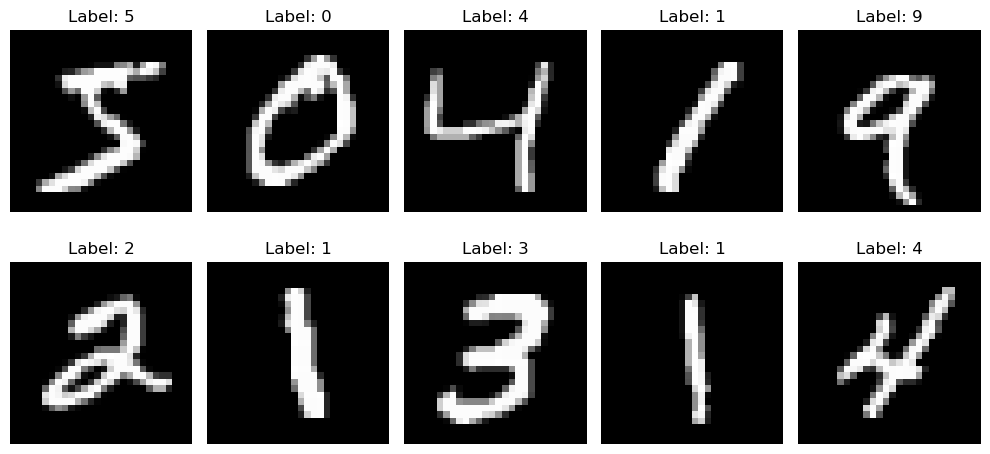

In [7]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


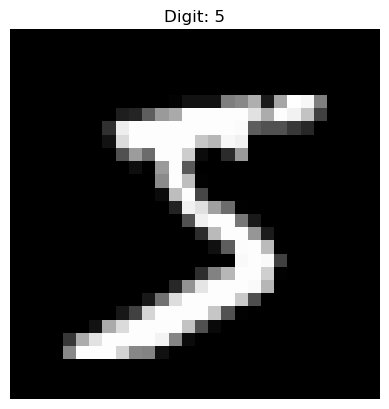

In [11]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis('off')
plt.show()

### Regularization
Added **Dropout** layers (0.3 and 0.2) after the dense layers, plus **EarlyStopping** (monitored on `val_loss`, patience=3) to reduce overfitting seen in the original run, where training accuracy kept climbing (~99.7%) while validation loss started increasing after a few epochs.

In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    callbacks=[early_stop]
)

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
y_prob = model.predict(X_test)

y_pred = y_prob.argmax(axis=1)

print("First 20 predictions:")
print(y_pred[:20])

print("\nActual labels:")
print(y_test[:20])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
incorrect_indices = np.where(y_pred != y_test)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

In [ ]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Actual: {y_test[idx]}\nPredicted: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()